# Utility

To evaluate the Utility of the anonymized datasets, we assess their impact on a downstream classification task. <br>
**Utility** is defined as the ability of the data to preserve predictive perfomrance after anonymization. We consider the prediciton of the attribute **age_group**, as it was the target attribute defined for the dataset. 

Identical machine learning models are trained on the original, the anonymized datasets, and the synthetic dataset, by using the same features and preprocessing. <br>
All models are evaluated on the same held-out original test to ensure comparability. <br>
For the traditionally anonymied dataset, record-level alignment allows a consistent train/test split across original and anonymized data. <br> 
For the synthetic dataset, where there is no record-level correspondence preserved, we adopt a train-on-synthetic, test-on-real (TSTR) protocol to assess how well models trained on synthetic data generalize to real indivicuals.

Performance differences between the three models are attributed to the effects of anonymization and are used to quantify utility loss.

We'll perform the comparison for both the anonymized dataset with the generalized BMI attribute and without the BMI attribute, against the original dataset and the synthetic dataset.

## BMI comparison

Models are evaluated in the released representation: the anonymized pipeline is tested on the held-out real records after applying the same BMI binning, while the synthetic pipeline is tested on held-out real records in the original schema.

In [ ]:
import pandas as pd

df_orig = pd.read_csv("../NHANES_2.csv") # dataset with binary classification of Diabetes + No attribute Age
df_synth = pd.read_csv("../synthetic data/synthetic_NHANES.csv")

df_anon_bmi = pd.read_csv("../traditional data/Traditionally_anon_NHANES_BMI.csv")
df_orig_anon = pd.read_csv("../NHANES_2.csv")

def bin_BMI(bmi):
    if bmi < 25: return "<25"
    else: return ">25"

df_orig_anon["BMI"] = df_orig_anon["BMI"].apply(bin_BMI)  # overwrite BMI with binned version

In [ ]:
TARGET = "age_group"
FEATURES_ORIG  = [c for c in df_orig.columns if c not in [TARGET, "rid"]]     # includes BMI
FEATURES_ANON  = [c for c in df_anon_bmi.columns if c not in [TARGET, "rid"]] # NO_BMI (and any other generalization)
FEATURES_SYNTH = [c for c in df_synth.columns if c != TARGET]                 # as generated

In [ ]:
from sklearn.model_selection import train_test_split

for df in (df_orig, df_orig_anon, df_anon_bmi):
    df.reset_index(drop=True, inplace=True)
    df["rid"] = df.index


train_ids, test_ids = train_test_split(
    df_orig["rid"],
    test_size=0.2,
    random_state=42, #seed
    stratify=df_orig[TARGET] # to force train/test split to preserve the class dist on the target variable
)

# build train and test set for original dataset (to compare it with synthetic dataset)
train_orig = df_orig[df_orig["rid"].isin(train_ids)].reset_index(drop=True)
test_orig  = df_orig[df_orig["rid"].isin(test_ids)].reset_index(drop=True)

# build train and test set for original dataset generalized (to compare it with traditionally anonymized dataset)
train_orig_anon = df_orig_anon[df_orig_anon["rid"].isin(train_ids)].reset_index(drop=True)
test_orig_anon  = df_orig_anon[df_orig_anon["rid"].isin(test_ids)].reset_index(drop=True)

# build train set for anonymized dataset
train_anon_bmi = df_anon_bmi[df_anon_bmi["rid"].isin(train_ids)].reset_index(drop=True)

In [ ]:
# Original training set
X_train_orig = train_orig[FEATURES_ORIG]
y_train_orig = train_orig[TARGET]

# Common test set for original and synthetic datasets
X_test_orig = test_orig[FEATURES_ORIG]
y_test_orig = test_orig[TARGET]

# Synthetic training set
X_train_synth = df_synth[FEATURES_SYNTH]
y_train_synth = df_synth[TARGET]



# Original binned training set
X_train_orig_anon = train_orig_anon[FEATURES_ANON]
y_train_orig_anon = train_orig_anon[TARGET]

# Anonymized bmi
X_train_anon = train_anon_bmi[FEATURES_ANON]
y_train_anon = train_anon_bmi[TARGET]

# test set for traditionally anonymized dataset
X_test_anon = test_orig_anon[FEATURES_ANON]
y_test_anon = test_orig_anon[TARGET]

### Baseline Comparison

With the Majority-class baseline, our orig model should outperform this. 
From scikitlearn: "The dummy classifier makes predictions that ignore the input features. The classifier serves as a simple baseline to compare against other more complex classifiers".

Here we used the parameter strategy = "most frequent": the predict method always returns the most frequent class label in the observed y argument passed to fit.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

def eval_dummy(X_train, y_train, X_test, y_test, name):
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    print(f"\nDummy baseline — {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))

# Baseline for original/synthetic evaluation (original schema)
eval_dummy(X_train_orig, y_train_orig, X_test_orig, y_test_orig, "Original/Synthetic (orig schema)")

# Baseline for anonymized evaluation (binned schema)
eval_dummy(X_train_orig_anon, y_train_orig_anon, X_test_anon, y_test_anon, "Traditional anonymization (binned schema)")


* Accuracy: measures the proportion of correctly classified instances $$Accuracy = \frac{Number\ of\  correct\  predictions}{Total\  number\  of\  predictions} = \frac{True \ Positives + True \ Negatives}{Total}$$
* Macro-averaged F1-score: for a single class is the harmonic mean of precision and recall $$F1_c = 2 \cdot \frac{Precision_c \cdot Recall_c}{Precision_c + Recall_c}$$ where 
    - precision: proportion of correct predictions among all predictions for that class
     $Precision_c = \frac{True \ Positives_c}{True \ Positives_c + False \ Positives_c}$
    - recall: proportion of correctly identified instances among all true instances of that class.
    $Recall_c = \frac{True \ Positives_c}{True \ Positives_c + False\ Negatives_c}$

    - Properties: 
        - High if both precision and recall are high
        - If either is 0, F1 is 0

* Macro-F1 is computed as: $Macro-F1 = \frac{1}{K}\sum_{c=1}^{K}F1_c$ with K classes (3).
    So each class contributes equally and class frequency doesn't matter.

Macro-averaged F1-score was used as the primary evaluation metric. Macro-F1 computes the F1-score independently for each class and then averages them, assigning equal importance to all classes. This choice mitigates the effect of class imbalance and provides a balanced assessment of predictive performance across admission types.

The dummy baseline yields identical performance across evaluation tracks, as expected, since the target distribution is preserved by BMI binning and the baseline ignores feature information. Differences observed with trained models therefore reflect the utility contributed by the released representations. 

### Pre-processing: One-Hot encoding

In [ ]:
from sklearn.compose import ColumnTransformer # to apply different preprocessing steps to different columns
from sklearn.preprocessing import OneHotEncoder # to convert categorical values into binary indicator variables
from sklearn.preprocessing import StandardScaler

# original and synthetic (BMI numeric)
cat_features_1 = ["Gender", "Physical Activity", "Diabetes_bin"] 
num_features_1 = ["Glucose Level", "Oral Glucose Test", "Insulin Level", "BMI"]

# traditional anonymized (BMI binned -> categorical)
cat_features_2 = ["Gender", "Physical Activity", "Diabetes_bin", "BMI"] 
num_features_2 = ["Glucose Level", "Oral Glucose Test", "Insulin Level"]




preprocess_1 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features_1), # avoid hot encoding binary variables
        ("num", StandardScaler(), num_features_1),
    ],
    remainder = "drop"
)

preprocess_2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features_2), # avoid hot encoding binary variables
        ("num", StandardScaler(), num_features_2),
    ],
    remainder = "drop"
)

With this pre-processing step we're defining a feature transformation pipeline that:
* converts categorical attributes into a numerical representation
* handles generalized and suppressed values safely
* ensures the same transformations are applied to both datasets

Pre-processing is needed because most ML algorithms can't directly operate on strings, but they require a numerical input

### Logistic Regression pipeline

Logistic Regression is a supervised ML algorithm used for classification tasks. Rather than predicting continuous values, it estimates the probability that an input instance belongs to a given class and assigns the class with the highest probability. In its binary formulation, Logistic Regression models the probability of a class using a weighted linear combination of the input features, which is transformed into a value between 0 and 1 through the sigmoid function. Model parameters are learned by maximizing the likelihood of the observed training data.

In our case we use the Multinomial Logistic Regression, which extends binary logistic regression to handle multiple classes, in our case we have 3 classes to consider. In multinomial Logistic Regression we use the softmax function instead of the sigmoid function.
Given an input feature vector 𝑥, the probability of assigning class 𝑐 is computed as: $P(y=c|x)= \frac {e^{w_c^T\cdot x + b_c}}{\sum _{k=1}^{K}e^{w_k^T \cdot x + b_k}}$, where K denotes the number of classes, and $w_c$ and $b_c$ are the parameters associated with class c. The model learns the the set of parameters that best separate the classes by maximizing the likelihood of the training data.

In our study, a multinomial Logistic Regression classifier was employed to model the probability of each admission type as a function of the input features. Categorical attributes were one-hot encoded, and the classifier was trained separately on the original and anonymized datasets. This setup allows us to assess the impact of anonymization on linear class separability and predictive utility.

Class weighting was enabled to compensate for class imbalance, ensuring that minority classes contribute proportionally to the training objective and that Macro-F1 reflects genuine discriminative performance rather than majority-class dominance

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)


# for synthetic and original dataset
logreg_1 = Pipeline([
    ("prep", preprocess_1),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        class_weight = "balanced",
        n_jobs=-1
    ))
])

for name, X_tr, y_tr in [
    ("Original", X_train_orig, y_train_orig),
    ("Synthetic", X_train_synth, y_train_synth),
]:
    logreg_1.fit(X_tr, y_tr)
    y_pred = logreg_1.predict(X_test_orig)

    print(f"LogReg – trained on {name}")
    print("Accuracy:", accuracy_score(y_test_orig, y_pred))
    print("Macro-F1:", f1_score(y_test_orig, y_pred, average="macro"))
    print()

# for traditional anonymized
logreg_2 = Pipeline([
    ("prep", preprocess_2),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        class_weight = "balanced",
        n_jobs=-1
    ))
])

logreg_2.fit(X_train_anon, y_train_anon)
y_pred = logreg_2.predict(X_test_anon)

print("LogReg – trained on Traditional anonymized (BMI binned)")
print("Accuracy:", accuracy_score(y_test_anon, y_pred))
print("Macro-F1:", f1_score(y_test_anon, y_pred, average="macro"))
print()

### Random Forest pipeline

Random Forest is an ensemble learning method that combines multiple decision trees trained on bootstrap samples of the data and random subsets of features. This approach improves robustness and reduces overfitting. In our experiments, Random Forest classifiers were trained separately on the original and anonymized datasets using identical configurations, allowing us to evaluate the impact of anonymization on non-linear classification performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_1 = Pipeline([
    ("prep", preprocess_1),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

for name, X_tr, y_tr in [
    ("Original", X_train_orig, y_train_orig),
    ("Synthetic", X_train_synth, y_train_synth),
]:
    rf_1.fit(X_tr, y_tr)
    y_pred = rf_1.predict(X_test_orig)

    print(f"RF – trained on {name}")
    print("Accuracy:", accuracy_score(y_test_orig, y_pred))
    print("Macro-F1:", f1_score(y_test_orig, y_pred, average="macro"))
    print()

from sklearn.ensemble import RandomForestClassifier

rf_2 = Pipeline([
    ("prep", preprocess_2),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_2.fit(X_train_anon, y_train_anon)
y_pred = rf_2.predict(X_test_anon)
print("RF – trained on Traditional anonymized (BMI binned)")
print("Accuracy:", accuracy_score(y_test_anon, y_pred))
print("Macro-F1:", f1_score(y_test_anon, y_pred, average="macro"))
print()

## NO BMI comparison

In [ ]:
import pandas as pd

df_orig = pd.read_csv("../NHANES_2.csv")

# Load anonymized NO_BMI dataset + make a NO_BMI view of original
df_anon_no_bmi = pd.read_csv("../traditional data/Traditionally_anon_NHANES_NO_BMI.csv")
df_orig_no_bmi = df_orig.drop(columns=["BMI"]).copy()

In [ ]:
TARGET = "age_group"
FEATURES_NO_BMI = [c for c in df_anon_no_bmi.columns if c not in [TARGET, "rid"]]

In [ ]:
from sklearn.model_selection import train_test_split

for df in (df_orig, df_orig_no_bmi, df_anon_no_bmi):
    df.reset_index(drop=True, inplace=True)
    df["rid"] = df.index


train_ids, test_ids = train_test_split(
    df_orig["rid"],
    test_size=0.2,
    random_state=42, #seed
    stratify=df_orig[TARGET] # to force train/test split to preserve the class dist on the target variable
)

# build train and test set for original dataset generalized (to compare it with traditionally anonymized dataset)
train_orig_no_bmi = df_orig_no_bmi[df_orig_no_bmi["rid"].isin(train_ids)].reset_index(drop=True)
test_orig_no_bmi  = df_orig_no_bmi[df_orig_no_bmi["rid"].isin(test_ids)].reset_index(drop=True)

# build train set for anonymized dataset
train_anon_no_bmi = df_anon_no_bmi[df_anon_no_bmi["rid"].isin(train_ids)].reset_index(drop=True)

In [ ]:
X_train_orig_no_bmi = train_orig_no_bmi[FEATURES_NO_BMI]
y_train_orig_no_bmi = train_orig_no_bmi[TARGET]

X_train_anon_no_bmi = train_anon_no_bmi[FEATURES_NO_BMI]
y_train_anon_no_bmi = train_anon_no_bmi[TARGET]

X_test_no_bmi = test_orig_no_bmi[FEATURES_NO_BMI]
y_test_no_bmi = test_orig_no_bmi[TARGET]

### Baseline Comparison

In [ ]:
# Baseline for anonymized evaluation (binned schema)
eval_dummy(X_train_orig_no_bmi, y_train_orig_no_bmi, X_test_no_bmi, y_test_no_bmi, "Traditional anonymization (suppressed schema)")

### Pre-processing: One-Hot encoding

In [ ]:
from sklearn.compose import ColumnTransformer # to apply different preprocessing steps to different columns
from sklearn.preprocessing import OneHotEncoder # to convert categorical values into binary indicator variables
from sklearn.preprocessing import StandardScaler

cat_features = ["Gender", "Physical Activity", "Diabetes_bin"] 

# traditional anonymized (BMI binned -> categorical)
num_features = ["Glucose Level", "Oral Glucose Test", "Insulin Level"]

preprocess_3 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features), # avoid hot encoding binary variables
        ("num", StandardScaler(), num_features),
    ],
    remainder = "drop"
)

### Logistic Regresion pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

# for traditional anonymized
logreg_3 = Pipeline([
    ("prep", preprocess_3),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        class_weight = "balanced",
        n_jobs=-1
    ))
])

logreg_3.fit(X_train_anon_no_bmi, y_train_anon_no_bmi)
y_pred = logreg_3.predict(X_test_no_bmi)

print("LogReg – trained on Traditional anonymized (BMI suppressed)")
print("Accuracy:", accuracy_score(y_test_no_bmi, y_pred))
print("Macro-F1:", f1_score(y_test_no_bmi, y_pred, average="macro"))
print()

### Random Forest pipeline

In [ ]:
rf_3 = Pipeline([
    ("prep", preprocess_3),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_3.fit(X_train_anon_no_bmi, y_train_anon_no_bmi)
y_pred = rf_3.predict(X_test_no_bmi)
print("RF – trained on Traditional anonymized (BMI suppressed)")
print("Accuracy:", accuracy_score(y_test_no_bmi, y_pred))
print("Macro-F1:", f1_score(y_test_no_bmi, y_pred, average="macro"))
print()

## Results

 Model | Dataset | Accuracy | Macro-F1|
| :--- | :--- | :--- | :--- |
|**Dummy Baseline** |  | 0.8399122807017544| 0.4564958283671037|
| | | | |
| | | | |
| **Logistic Regression** | Original Dataset |  0.6907894736842105| 0.6002660913787636 |
| | Synthetic Dataset|  0.6710526315789473| 0.5781423461206365| 
|  | BMI dataset |  0.6820175438596491| 0.5953859804791481| 
| | NO BMI dataset | 0.6929824561403509| 0.5976098630965887|
| | | | |
| | | | |
| **Random Forests** | Original Dataset  |0.8421052631578947 | 0.5647932131495228|
| | Synthetic Dataset |0.8421052631578947 |0.47055408630587625 |
|  | BMI dataset |   0.8421052631578947|0.5884270169984456| 
| | NO BMI dataset| 0.8442982456140351| 0.5749340265469298|

The table shows the results for the age_group classification task across different datasets and models, using Accuracy and Macro-F1 as evaluation metrics. <br>
Due to the strong class imbalance in the target variable, Accuracy is largely dominated by the majority class, while Macro-F1 provides a more informative measure of performance across all classes.

**Dummy Baseline** <br>
The dummy baseline, which always predicts the majority class, achieves a high Accuracy (0.840) but a low Macro-F1. This result confirms that naive classifiers can obtain seemingly good Accuracy without capturing meaningful discriminatory information, motivating the use of Macro-F1 as the primary utility metric.

**Logistic Regression**<br>
Logistic Regression achieves the highest Macro-F1 when trained on the original dataset (0.600), which serves as an upper bound on achievable utility. Training on the synthetic dataset results in a noticeable drop in performance (Macro-F1 = 0.578), indicating some loss of task-relevant structure during data generation.

The traditionally anonymized datasets perform competitively: the BMI-binned dataset attains a Macro-F1 of 0.595, while the BMI-suppressed dataset achieves 0.598. These results suggest that, for a linear model, traditional anonymization preserves predictive signal remarkably well, and that complete suppression of BMI does not substantially degrade performance compared to coarse generalization.

**Random Forests**<br>
Random Forest models achieve uniformly high Accuracy (≈0.842) across all datasets, closely matching the dummy baseline and again highlighting the limited informativeness of Accuracy in this imbalanced setting. Macro-F1, however, reveals substantial differences.

The original dataset yields a Macro-F1 of 0.565, while the synthetic dataset exhibits a marked reduction (0.471), indicating that Random Forests are particularly sensitive to distortions in feature distributions introduced by synthetic data generation. In contrast, the traditionally anonymized BMI-binned dataset achieves the highest Macro-F1 (0.588), outperforming both the original and synthetic datasets. This suggests that tree-based models are robust to coarse discretization and can effectively exploit binned attributes.

For the BMI-suppressed dataset, Random Forest performance decreases relative to the binned case, confirming that the complete removal of BMI reduces the model’s ability to separate minority classes, even when class weighting is applied.

**Overall comparison**
Across both classifiers, we can see that the original dataset has the highest utility, the traditionally anonymized datasets (especially with BMI binning) retain most of the predictive power, and the synthetic dataset exhibits the largest utility loss, particularly for the Random Forest classifier. <br>
These results show that traditional anonymization can preserve utility as well as, or better than traditional anonymization can preserve downstream utility as well as, or better than, synthetic data generation for this task, while the impact of attribute generalization versus suppression is strongly model-dependent.

# Environmental sustainability

Environmental sustainability is the second aspect we will consider to compare synthetic data generation and traditional privacy preserving techniques. <br>
In order to do so, we can use CodeCarbon, which is a tracking tool designed to assess the climate impact of a computer program. <br>
Therefore, we will measure the whole process of generating the two different datasets and then we will confront them.

## Constant Mode

**CPU metrics priority** (from codecarbon's methodology section): <br>
CodeCarbon will first try to read the energy consumption of the CPU from low level interface like RAPL or powermetrics. If none of the tracking tools are available, CodeCarbon will be switched to a fallback mode:
* It will first detect which CPU hardware is currently in use, and then map it to a data source listing 2000+ Intel and AMD CPUs and their corresponding thermal design powers (TDPs).
* If the CPU is not found in the data source, a global constant will be applied.
* If psutil is available, CodeCarbon will try to estimate the energy consumption from the TDP and the CPU load.
* CodeCarbon assumes that 50% of the TDP will be the average power consumption to make this approximation.

For actual CPU usage the Intel Power Gadget (now discontinued) could track Intel processors. We should install the Performance Counter Monitor as it is the recommended alternative.


**How CodeCarbon Works:** <br>
CodeCarbon uses a scheduler that, by default, calls for a measure every 15 seconds, so it has no significant overhead.<br>
The measure itself is fast and CodeCarbon is designed to be as light as possible with a small memory footprint.<br>
The scheduler is started when the first start method is called and stopped when stop method is called.<br>
Another scheduler (_scheduler_monitor_power) is used to monitor only the power consumption of the hardware every second. It is needed for hardware that do not have energy counters but only instant power, like in CPU load mode.

In the log I got [codecarbon WARNING @ 10:24:41] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
Windows OS detected: Please install Intel Power Gadget to measure CPU
So I have downloaded Intel Power Gadget

## Synthetic Data Generation

In [ ]:
from codecarbon import OfflineEmissionsTracker
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer
import os
master_file = "synth_emissions.csv"
temp_file = "temp_emissions.csv"

tracker = OfflineEmissionsTracker(
    project_name="synthetic data generation",
    output_file=temp_file,
    output_dir = "C:\\Users\\rashm\\OneDrive\\Desktop\\uni\\tesi\\tesi\\NHANES_dataset\\comparison",
    measure_power_secs=1,
    tracking_mode = "process",
    country_iso_code="ITA",
    on_csv_write = "append"
)

# let's track the emissions
tracker.start()
df = pd.read_csv("../NHANES_2.csv")

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df)

metadata.validate()
metadata.validate_data(data=df)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)
rows = len(df)
synthetic_data = synthesizer.sample(num_rows = rows)
synthetic_df = pd.DataFrame(synthetic_data)
synthetic_df.to_csv('synthetic_NHANES.csv', index=False)

df.keys()

tracker.stop()

if os.path.exists(temp_file):
    new_data = pd.read_csv(temp_file)
    
    if os.path.exists(master_file):
        # If master exists, append WITHOUT headers
        # 'mode="a"' means append
        new_data.to_csv(master_file, mode='a', header=False, index=False)
    else:
        # If master doesn't exist, create it WITH headers
        new_data.to_csv(master_file, index=False)
    
    # Clean up the temp file so next run is fresh
    os.remove(temp_file)
    print(f"Successfully appended run to {master_file}")
else:
    print("Error: No data was generated by CodeCarbon.")

In [ ]:
df = pd.read_csv("synth_emissions.csv")

# Give each run a clear name
df["run"] = [f"run_{i+1}" for i in range(len(df))]

df_t = df.set_index("run").T

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(df_t)

We're interested only in some fields, so we can analyze just them and even normalize them:

In [ ]:
df = pd.read_csv("synth_emissions.csv")

key_metrics = df[[
    "duration",
    "energy_consumed",
    "emissions",
    "emissions_rate",
    "cpu_energy",
    "gpu_energy",
    "ram_energy",
    "energy_consumed",
    "water_consumed"
]]

print(key_metrics)

In [ ]:
summary = key_metrics.agg(["mean", "std"])
print(summary)

In [ ]:
n_records = len(pd.read_csv("synthetic_NHANES.csv"))

df["co2_per_10k"] = df["emissions"] / n_records * 10_000
df["energy_per_10k"] = df["energy_consumed"] / n_records * 10_000

df[["co2_per_10k", "energy_per_10k"]]
df[["co2_per_10k", "energy_per_10k"]].agg(["mean", "std"])

## Traditional privacy preserving techniques

Now we want to check the emissions produced by the generation of the anonymized dataset, obtained with traditional privacy preserving techniques. 

Carbon emissions were measured only for the transformations applied to the final released dataset. Exploratory steps, including privacy metric evaluations and anonymization of attributes that were ultimately suppressed, were excluded to ensure that the reported footprint reflects the cost of producing the published data rather than the development process

### BMI

In this anonymization process we took into consideration the evaluation of the achieved k-level, as it is determining to decide whether to continue the generalization process in order to achieve the minimum k-level target.

In [ ]:
import os
from codecarbon import OfflineEmissionsTracker
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from pycanon import anonymity


temp_file = "temp_emissions.csv"
master_file = "anon_emissions_BMI.csv"

tracker = OfflineEmissionsTracker(
    project_name="traditional anonymization BMI",
    output_file=temp_file,
    output_dir = "C:\\Users\\rashm\\OneDrive\\Desktop\\uni\\tesi\\tesi\\NHANES_dataset\\comparison",
    measure_power_secs=1,
    tracking_mode = "process",
    country_iso_code="ITA",
    on_csv_write = "append"
)

# let's track the emissions
tracker.start()

def calculate_k_anon(df, quasi_identifiers):
    k = anonymity.k_anonymity(df, quasi_identifiers)
    print(f"k-anonymity of the dataset: {k}")

critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI']

df = pd.read_csv("../NHANES_2.csv")
df["Physical Activity"].value_counts(dropna=False)
df = df[df["Physical Activity"] != "Unknown"]
df["age_group"].value_counts(dropna=False)
df["Gender"].value_counts(dropna=False)

def bin_BMI_1(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 25: return "18.5-25"
    elif bmi <= 30: return "25-30"        
    else: return ">30"    

df['BMI_binned'] = df['BMI'].apply(bin_BMI_1)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned']
calculate_k_anon(df, quasi_identifiers)

def bin_BMI_2(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 24.9: return "18.5-24.9"
    else: return ">25" 

df['BMI_binned_2'] = df['BMI'].apply(bin_BMI_2)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_2']
calculate_k_anon(df, quasi_identifiers)

def bin_BMI_3(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 24.9: return "18.5-24.9"
    else: return ">25" 

df['BMI_binned_3'] = df['BMI'].apply(bin_BMI_3)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_3']
calculate_k_anon(df, quasi_identifiers)

def bin_BMI_4(bmi):
    if bmi < 24.9: return "<25"
    else: return ">25"

df['BMI_binned_4'] = df['BMI'].apply(bin_BMI_4)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_4']
calculate_k_anon(df, quasi_identifiers)

df = df.drop(columns=["BMI", "BMI_binned","BMI_binned_2", "BMI_binned_3"])
df = df.rename(columns = {"BMI_binned_4":"BMI"})
df.to_csv("Traditionally_anon_NHANES_BMI.csv", index = False)

tracker.stop()

if os.path.exists(temp_file):
    new_data = pd.read_csv(temp_file)
    
    if os.path.exists(master_file):
        # If master exists, append WITHOUT headers
        # 'mode="a"' means append
        new_data.to_csv(master_file, mode='a', header=False, index=False)
    else:
        # If master doesn't exist, create it WITH headers
        new_data.to_csv(master_file, index=False)
    
    # Clean up the temp file so next run is fresh
    os.remove(temp_file)
    print(f"Successfully appended run to {master_file}")
else:
    print("Error: No data was generated by CodeCarbon.")

In [ ]:
df = pd.read_csv("anon_emissions_BMI.csv")

# Give each run a clear name
df["run"] = [f"run_{i+1}" for i in range(len(df))]

df_t = df.set_index("run").T

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(df_t)

In [ ]:
key_metrics = df[[
    "duration",
    "energy_consumed",
    "emissions",
    "emissions_rate",
    "cpu_energy",
    "gpu_energy",
    "ram_energy",
    "water_consumed"
]]

print(key_metrics)

In [ ]:
summary = key_metrics.agg(["mean", "std"])
print(summary)

In [ ]:
n_records = len(pd.read_csv("Traditionally_anon_NHANES_BMI.csv"))

df["co2_per_10k"] = df["emissions"] / n_records * 10_000
df["energy_per_10k"] = df["energy_consumed"] / n_records * 10_000

df[["co2_per_10k", "energy_per_10k"]]
df[["co2_per_10k", "energy_per_10k"]].agg(["mean", "std"])

### NO BMI

In [ ]:
from codecarbon import OfflineEmissionsTracker
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

temp_file = "temp_emissions.csv"
master_file = "anon_emissions_NO_BMI.csv"

tracker = OfflineEmissionsTracker(
    project_name="traditional anonymization NO BMI",
    output_file=temp_file,
    output_dir = "C:\\Users\\rashm\\OneDrive\\Desktop\\uni\\tesi\\tesi\\NHANES_dataset\\comparison",
    measure_power_secs=1,
    tracking_mode = "process",
    country_iso_code="ITA",
    on_csv_write = "append"
)

# let's track the emissions
tracker.start()

df = pd.read_csv("../NHANES_2.csv")
df = df[df["Physical Activity"] != "Unknown"]
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity']
# --- Compute k-anonymity ---
calculate_k_anon(df, quasi_identifiers)

df = df.drop(columns="BMI")
df.to_csv("Traditionally_anon_NHANES_NO_BMI.csv", index = False)

tracker.stop()

if os.path.exists(temp_file):
    new_data = pd.read_csv(temp_file)
    
    if os.path.exists(master_file):
        # If master exists, append WITHOUT headers
        # 'mode="a"' means append
        new_data.to_csv(master_file, mode='a', header=False, index=False)
    else:
        # If master doesn't exist, create it WITH headers
        new_data.to_csv(master_file, index=False)
    
    # Clean up the temp file so next run is fresh
    os.remove(temp_file)
    print(f"Successfully appended run to {master_file}")
else:
    print("Error: No data was generated by CodeCarbon.")

In [ ]:
df = pd.read_csv("anon_emissions_NO_BMI.csv")

# Give each run a clear name
df["run"] = [f"run_{i+1}" for i in range(len(df))]

df_t = df.set_index("run").T

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(df_t)

In [ ]:
key_metrics = df[[
    "duration",
    "energy_consumed",
    "emissions",
    "emissions_rate",
    "cpu_energy",
    "gpu_energy",
    "ram_energy",
    "water_consumed"
]]

print(key_metrics)

In [ ]:
summary = key_metrics.agg(["mean", "std"])
print(summary)

In [ ]:
n_records = len(pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv"))

df["co2_per_10k"] = df["emissions"] / n_records * 10_000
df["energy_per_10k"] = df["energy_consumed"] / n_records * 10_000

df[["co2_per_10k", "energy_per_10k"]]
df[["co2_per_10k", "energy_per_10k"]].agg(["mean", "std"])

## Results

From codecarbon's documentation:
* duration (in seconds)
* energy_consumed: sum of cpu_energy, gpu_energy and ram_energy (kWh)
* emissions: emissions as CO₂-equivalents [CO₂eq], in kg
* emissions_rate: emissions divided per duration, in Kg/s
* cpu_energy: Mean CPU power (W)
* gpu_energy: Mean GPU power (W)
* ram_energy: Mean RAM power (W)
* water_consumed

| Method               | Duration (s) | Energy Consumed (kWh) | CO₂ emissions (kg CO₂eq)| CO₂ / 10k records | Energy / 10k records |
|----------------------|--------------|--------------|---------------|-------------------|----------------------|
| Synthetic Generation |  2.0290±0.2777 |  0.000014 ± 0.000004  | 0.000005 ± 0.000001 |    0.000021	±   0.000006   |    0.000063   ±  0.000019  |
| Anonymization  BMI     |1.141374  ±0.041759 | 0.000006 ± 0.000001 | 1.844074e-06  ±  4.555630e-07 |   0.000008  ±  0.000002    |    0.000024   ±   0.000006    |
| Anonymization NO BMI    |1.192283 ± 0.032989|   0.000004  ±0.000002| 1.247951e-06  ± 7.003427e-07  |   0.000005  ±   0.000003   |  0.000017    ±   0.000009     |

The carbon footprint of traditional anonymization and synthetic data generation was evaluated using CodeCarbon, with each experiment repeated three times. <br>
Results show that synthetic data generation incurs a higher computational cost than anonymization across all considered metrics. <br>
When normalized per 10,000 records, synthetic data generation produced approximately 2.1×10⁻⁵ kg CO₂eq, compared to 8×10⁻⁶ kg CO₂eq for anonymization, corresponding to an increase by a factor greater than three. A similar trend was observed for energy consumption and execution time.<br>
Synthetic Data also exhibits higher variability over different runs, while anonymization methods show more stable and predictable resource consumption. <br>
Among anonymization approaches, excluding the BMI attribute further reduces emissions and energy usage, highlighting the impact of dataset dimensionality and quasi-identifier complexity on anonymization cost.

This difference can be largely attributed to the computational overhead associated with training and sampling generative machine learning models, while traditional anonymization is based on lightweight deterministic transformations. <br>
Although absolute emissions are small at this scale, these differences become relevant in large-scale or repeated data release scenarios. 

Overall, the results highlight an often-overlooked trade-off between privacy methodology and environmental sustainability: synthetic data generation, while offering distinct privacy and utility properties, comes at a significantly higher environmental cost.

# Privacy

The last object of our comparison is the level of privacy obtained for both the synthetic dataset and the traditionally-anonymized one. 

We use the same privacy metrics and attacker assumptions to enable a fair comparison between deterministic anonymization and probabilistic synthetic data generation. <br>
As we did during the generation of the traditionally-anonymized dataset, we should first define an attacker model: we will consider the attacker to know the same quasi-identifiers that were considered in the traditional approach and we assume the attacker tries to infer sensitive attributes or re-identify individuals.

We'll compare the traditionally anonymized dataset and the synthetic dataset under 2 scenarios:
1. the released as-is datasets: we want to compare the datasets as they are after the anonymization or the generation process, to assess their privacy level.
2. we'll compare the datasets with an aligned-representation: we want to see how the two release mechanisms compare in terms of privacy risk under the assumption that an attacker reasons over the same quasi-identifier granularity.

## Released as-is datasets

In this comparison we'll evaluate three datasets: the synthetic dataset, the traditionally anonymized dataset with the binned BMI attribute, and the traditionally anonymized dataset with the suppressed BMI attribute.

In [1]:
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers_1 = ['age_group', 'Gender', 'Physical Activity', 'BMI']
quasi_identifiers_2 = ['age_group', 'Gender', 'Physical Activity']

In [2]:
import pandas as pd

df_synth = pd.read_csv("../synthetic data/synthetic_NHANES.csv")
df_anon_bmi = pd.read_csv("../traditional data/Traditionally_anon_NHANES_BMI.csv")
df_anon_no_bmi = pd.read_csv("../traditional data/Traditionally_anon_NHANES_NO_BMI.csv")

There are several metrics that we could use to evaluate the privacy of our datasets, many of which were already used for the privacy evaluation of the traditionally-anonymized dataset:
* Indistinguishability-Based Metrics:
    * k-anonymity
    * l-diversity (per sensitive attribute)
    * t-closeness
* Re-identification Risk Metrics:
    * Prosecutor Risk $\rightarrow$ probability of re-identification given qis (approximated as $\frac{1}{equivalence \ class \ size}$)
* Attribute Disclosure Risk (Inference Attacks) $\rightarrow$ given qis, how well can an attacker guess a sensitive value?


### Indistinguishability-based metrics:

Although k-anonymity, l-diversity, and t-closeness were originally formulated for releases of real microdata, we apply these metrics to synthetic data as descriptive measures of structural privacy risk rather than as formal privacy guarantees. In particular, these metrics quantify the degree of record uniqueness and sensitive attribute concentration with respect to quasi-identifiers, which directly affects the feasibility of linkage and inference attacks. When applied to synthetic data, k/l/t metrics are therefore interpreted comparatively and in conjunction with empirical attack simulations, rather than as standalone guarantees.

We note that, unlike traditional anonymization, equivalence classes in synthetic data do not correspond to real individuals, and therefore k/l/t metrics should be interpreted as indicators of structural risk rather than formal privacy guarantees.

#### k-anonymity

In [3]:
from pycanon import anonymity

def calculate_k_anon(df, quasi_identifiers, name: str):
    k = anonymity.k_anonymity(df, quasi_identifiers)
    print(f"k-anonymity of {name}: {k}")

calculate_k_anon(df_synth, quasi_identifiers_1, "df_synth")
calculate_k_anon(df_anon_bmi, quasi_identifiers_1, "df_anon_bmi")
calculate_k_anon(df_anon_no_bmi, quasi_identifiers_2, "df_anon_no_bmi")

k-anonymity of df_synth: 1
k-anonymity of df_anon_bmi: 5
k-anonymity of df_anon_no_bmi: 11


In [4]:
def eq_class_sizes(df, qis):
    sizes = df.groupby(qis, dropna=False).size()
    return sizes

sizes_synth = eq_class_sizes(df_synth, quasi_identifiers_1)
sizes_anon_bmi  = eq_class_sizes(df_anon_bmi, quasi_identifiers_1)
sizes_anon_no_bmi  = eq_class_sizes(df_anon_no_bmi, quasi_identifiers_2)


print("SYNTH: min/median/mean:", sizes_synth.min(), sizes_synth.median(), sizes_synth.mean())
print("ANON BMI : min/median/mean:", sizes_anon_bmi.min(), sizes_anon_bmi.median(), sizes_anon_bmi.mean())
print("ANON NO BMI : min/median/mean:", sizes_anon_no_bmi.min(), sizes_anon_no_bmi.median(), sizes_anon_no_bmi.mean())


print("\nShare in classes <=5:")
print("SYNTH:", (sizes_synth[sizes_synth<=5].sum() / len(df_synth)))
print("ANON BMI:", (sizes_anon_bmi[sizes_anon_bmi<=5].sum() / len(df_anon_bmi)))
print("ANON NO BMI:", (sizes_anon_no_bmi[sizes_anon_no_bmi<=5].sum() / len(df_anon_no_bmi)))



SYNTH: min/median/mean: 1 1.0 2.0150442477876105
ANON BMI : min/median/mean: 5 85.5 142.3125
ANON NO BMI : min/median/mean: 11 165.5 284.625

Share in classes <=5:
SYNTH: 0.8647342995169082
ANON BMI: 0.0021958717610891525
ANON NO BMI: 0.0


The k-anonymity analysis highlights clear structural differences between the release mechanisms. The traditionally anonymized datasets satisfy explicit anonymity guarantees, with k = 5 when BMI is generalized and k = 11 when BMI is fully suppressed, reflecting the increased protection achieved through stronger attribute removal. In contrast, the synthetic dataset exhibits a minimum equivalence class size of one under the same quasi-identifiers, indicating the absence of enforced structural anonymity. This result is expected, as synthetic data generation does not impose equivalence-class constraints. Consequently, k-anonymity is interpreted here as a descriptive structural indicator rather than a formal privacy guarantee for synthetic data, motivating the use of attack-based evaluations in subsequent analyses.

#### l-diversity

In [5]:
def l_diversity(df, qi, crit_attr):
    l = anonymity.l_diversity(df, qi, crit_attr, gen = True)
    print(l)
    for x in critical_attributes:
        critical_attribute = [x]
        print(f"{x}")
        l_1 = anonymity.l_diversity(df, qi, critical_attribute, gen = True)
        print(f"l-diversity: {l_1} \n")

print("l-diversity for the synthetic dataset: \n")
l_diversity(df_synth, quasi_identifiers_1, critical_attributes)

print("l-diversity for the traditionally anonymized dataset (BMI): \n")
l_diversity(df_anon_bmi, quasi_identifiers_1, critical_attributes)

print("l-diversity for the traditionally anonymized dataset (NO BMI): \n")
l_diversity(df_anon_no_bmi, quasi_identifiers_2, critical_attributes)

l-diversity for the synthetic dataset: 

1
Diabetes_bin
l-diversity: 1 

Glucose Level
l-diversity: 1 

Oral Glucose Test
l-diversity: 1 

Insulin Level
l-diversity: 1 

l-diversity for the traditionally anonymized dataset (BMI): 

1
Diabetes_bin
l-diversity: 1 

Glucose Level
l-diversity: 5 

Oral Glucose Test
l-diversity: 5 

Insulin Level
l-diversity: 5 

l-diversity for the traditionally anonymized dataset (NO BMI): 

2
Diabetes_bin
l-diversity: 2 

Glucose Level
l-diversity: 11 

Oral Glucose Test
l-diversity: 11 

Insulin Level
l-diversity: 11 



|  l-diversity         | Synthetic Dataset  | Traditional Dataset NO BMI |Traditional Dataset NO BMI|
|----------------------|--------------|--------------|-------------|
| Diabetes_bin |  1 |   1   | 2
| Glucose Level   | 1  | 5  | 11
| Oral Glucose Test |  1 |  5   | 11
|  Insulin Level |   1  |   5  | 11

The l-diversity analysis further emphasizes the impact of equivalence class size on sensitive attribute protection. For the synthetic dataset, l-diversity equals one for all sensitive attributes, reflecting the prevalence of singleton or near-singleton equivalence classes and the resulting lack of within-class variability. This outcome is a direct consequence of low k-anonymity rather than an absence of global attribute diversity. In contrast, the traditionally anonymized datasets exhibit substantially higher l-diversity, particularly for continuous clinical attributes, with l = 5 when BMI is generalized and l = 11 when BMI is fully suppressed. These results indicate that traditional anonymization effectively increases uncertainty about sensitive attributes within equivalence classes, while l-diversity values for the synthetic dataset should be interpreted as structural indicators rather than formal privacy guarantees.

#### t-closeness

T-closeness further strengthens privacy guarantees by requiring that the distribution of sensitive attributes within each equivalence class remains close (at a distance no closer than t) to their distribution in the overall dataset. This protects against probabilistic inference attacks, where an adversary may not learn an exact value but can infer elevated risk levels.

t-closeness ranges from 0 to 1, 0 being the best result. Basically, it analyzes how close the critical attributes of the groups are compared to the rest of the population

In [6]:
def t_closeness(df, qi, crit_attr):
    t = anonymity.t_closeness(df, qi, crit_attr, gen = True)
    print(t)
    for x in critical_attributes:
        critical_attribute = [x]
        print(f"{x}")
        t_1 = anonymity.t_closeness(df, qi, critical_attribute, gen = True)
        print(f"t-closeness: {t_1} \n")

In [7]:
print("t_closeness for the synthetic dataset: \n")
t_closeness(df_synth, quasi_identifiers_1, critical_attributes)

print("t_closeness for the traditionally anonymized dataset (BMI): \n")
t_closeness(df_anon_bmi, quasi_identifiers_1, critical_attributes)

print("t_closeness for the traditionally anonymized dataset (NO BMI): \n")
t_closeness(df_anon_no_bmi, quasi_identifiers_2, critical_attributes)

t_closeness for the synthetic dataset: 

0.9600351339481774
Diabetes_bin
t-closeness: 0.9600351339481774 

Glucose Level
t-closeness: 0.6263793688119499 

Oral Glucose Test
t-closeness: 0.6560561290405108 

Insulin Level
t-closeness: 0.5438391476198723 

t_closeness for the traditionally anonymized dataset (BMI): 

0.2986385595081249
Diabetes_bin
t-closeness: 0.2986385595081249 

Glucose Level
t-closeness: 0.10183355292050943 

Oral Glucose Test
t-closeness: 0.23697163618112219 

Insulin Level
t-closeness: 0.2545206719028071 

t_closeness for the traditionally anonymized dataset (NO BMI): 

0.17662793947378921
Diabetes_bin
t-closeness: 0.14712340799297322 

Glucose Level
t-closeness: 0.09477382520860785 

Oral Glucose Test
t-closeness: 0.17662793947378921 

Insulin Level
t-closeness: 0.05989595014882165 



|  t-closeness             | Synthetic Dataset |Traditional Dataset BMI | Traditional Dataset NO BMI|
|----------------------|--------------|--------------|-------------|
| Diabetes_bin |  0.9600351339481774   |   0.2986385595081249   | 0.14712340799297322
| Glucose Level   | 0.6263793688119499  | 0.10183355292050943   | 0.09477382520860785 
| Oral Glucose Test |  0.6560561290405108  |  0.23697163618112219  | 0.17662793947378921 
|  Insulin Level |   0.5438391476198723   |   0.2545206719028071   |  0.05989595014882165

The t-closeness analysis further highlights the differences in how sensitive attribute distributions are preserved across release mechanisms. <br>
The synthetic dataset exhibits very high t-closeness values, indicating a substantial divergence between equivalence-class–level and global distributions. This behavior is primarily driven by the prevalence of small or singleton equivalence classes, in which sensitive attributes are highly concentrated. <br>
On the other hand, the traditionally anonymized datasets achieve markedly lower t-closeness, with the BMI-binned release exhibiting moderate divergence and the NO-BMI release achieving the lowest values overall. These results show that increasing the level of generalization or suppression leads to equivalence classes whose sensitive attribute distributions more closely resemble the global distribution, thereby reducing attribute disclosure risk under the t-closeness model. 

As with k-anonymity and l-diversity, t-closeness is interpreted here as a structural privacy indicator for synthetic data rather than a formal guarantee, motivating complementary attack-based analyses.

### Re-identification Risk

We can follow the same attack we implemented to evaluate the re-identification risk of the traditionally-anonymized dataset: we consider an external dataset obtained from the original one, but only with the attributes that could be retrieved from external data souces, the quasi-identifiers. 
* For the traditionally-anonymized dataset we check if there are any matches between the original one and the anonymized one. The higher the number of matches found per individual, the safer the dataset is. 

* For the synthetic dataset, we can use the attack to see if there could be attribute inference (predicting sensitive attributes for someone that has specific QIs): even though a real individual is not represented in the dataset, if someone has specific information (for example one attribute of that person is an outlier) and this information is replicated in the synthetic dataset, it's logical to assume the other information, even the sensitive one, would be similarly represented.

#### Simulation

In [8]:
import pandas as pd

def re_identify_individuals(external_df: pd.DataFrame, anon_df: pd.DataFrame, qi: list[str]):
    """
    Record linkage attack (exact matching on QIs).
    Returns:
      - match_hist: dict {num_matches: how_many_external_individuals}
      - matches_dict: dict {external_index: list_of_matching_released_indices}
    """

    # Make copies to avoid modifying original data
    ext = external_df.copy()
    df = anon_df.copy()

    for c in qi:
        ext[c] = ext[c].astype(str).str.strip()
        df[c] = df[c].astype(str).str.strip()

    matches_dict = {}

    # Exact-match linkage: filter released dataset step-by-step for each external row
    for ext_idx, row in ext.iterrows():
        candidates = df

        # to filter candidates by each QI
        for c in qi:
            candidates = candidates[candidates[c] == row[c]]
            if candidates.empty:
                break
        matches_dict[ext_idx] = list(candidates.index) # to store the indeces of the matched anon records

    # Build histogram: key = number of matches, value = how many external individuals
    match_hist = {}
    for match_list in matches_dict.values():
        m = len(match_list)
        match_hist[m] = match_hist.get(m, 0) + 1

    return match_hist, matches_dict

In [9]:
quasi_identifiers = ["BMI", "age_group", "Gender", "Physical Activity"]
external_dataset = pd.read_csv("../traditional data/external_dataset_BMI.csv", dtype=str)   # attacker knowledge
released_dataset = pd.read_csv("../traditional data/Traditionally_anon_NHANES_BMI.csv", dtype=str)  # published release

hist, per_person_matches_anon_bmi = re_identify_individuals(
    external_dataset,
    released_dataset,
    qi=quasi_identifiers
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

5 individuals have exactly 5 matches.
12 individuals have exactly 6 matches.
16 individuals have exactly 16 matches.
40 individuals have exactly 40 matches.
46 individuals have exactly 46 matches.
56 individuals have exactly 56 matches.
84 individuals have exactly 84 matches.
87 individuals have exactly 87 matches.
111 individuals have exactly 111 matches.
118 individuals have exactly 118 matches.
165 individuals have exactly 165 matches.
270 individuals have exactly 270 matches.
363 individuals have exactly 363 matches.
414 individuals have exactly 414 matches.
490 individuals have exactly 490 matches.


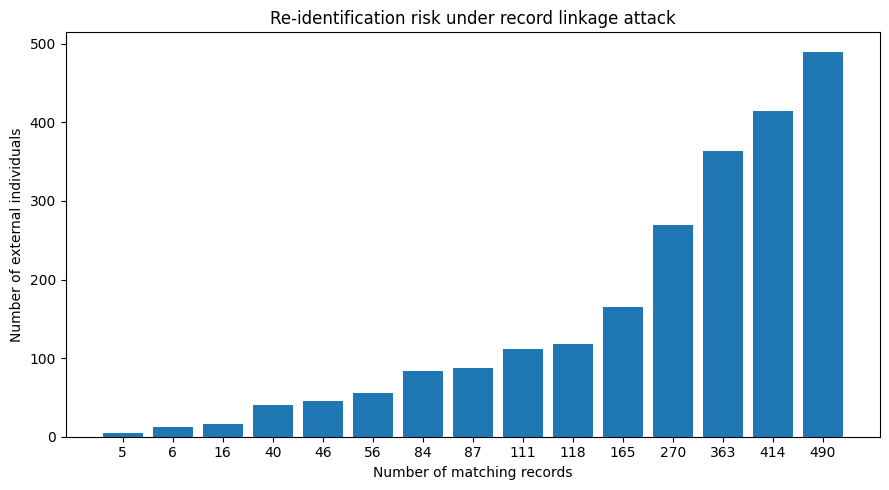

In [10]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


In [11]:
quasi_identifiers = ["BMI", "age_group", "Gender", "Physical Activity"]
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']

external_dataset = pd.read_csv("../NHANES_2.csv", dtype=str)   # attacker knowledge
external_dataset = external_dataset.drop(columns=critical_attributes)

released_dataset = pd.read_csv("../synthetic data/synthetic_NHANES.csv", dtype=str)  # published release

hist, per_person_matches_synth = re_identify_individuals(
    external_dataset,
    released_dataset,
    qi=quasi_identifiers
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

561 individuals have exactly 0 matches.
469 individuals have exactly 1 match.
287 individuals have exactly 2 matches.
355 individuals have exactly 3 matches.
262 individuals have exactly 4 matches.
173 individuals have exactly 5 matches.
95 individuals have exactly 6 matches.
52 individuals have exactly 7 matches.
18 individuals have exactly 8 matches.
5 individuals have exactly 9 matches.


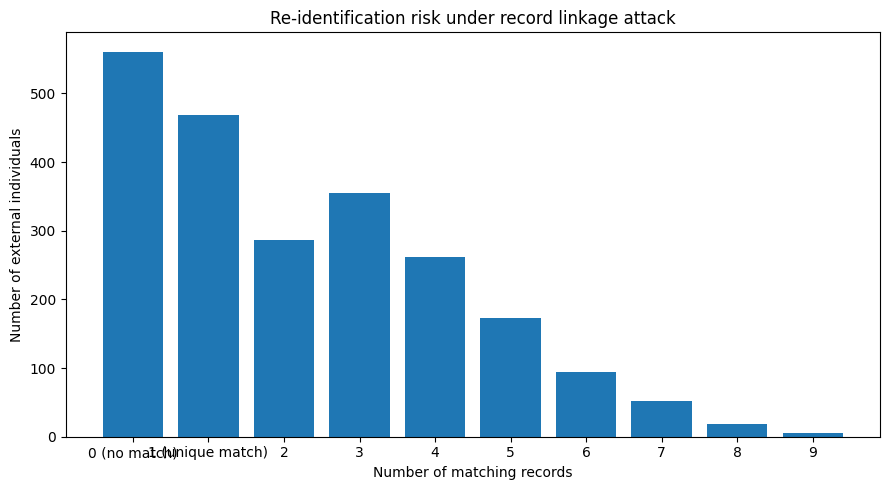

In [12]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


In [13]:
quasi_identifiers = ["age_group", "Gender", "Physical Activity"]
external_dataset = pd.read_csv("../traditional data/external_dataset_NO_BMI.csv", dtype=str)   # attacker knowledge
released_dataset = pd.read_csv("../traditional data/Traditionally_anon_NHANES_NO_BMI.csv", dtype=str)  # published release

hist, per_person_matches_anon_no_bmi = re_identify_individuals(
    external_dataset,
    released_dataset,
    qi=quasi_identifiers
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

11 individuals have exactly 11 matches.
22 individuals have exactly 22 matches.
127 individuals have exactly 127 matches.
157 individuals have exactly 157 matches.
174 individuals have exactly 174 matches.
249 individuals have exactly 249 matches.
684 individuals have exactly 684 matches.
853 individuals have exactly 853 matches.


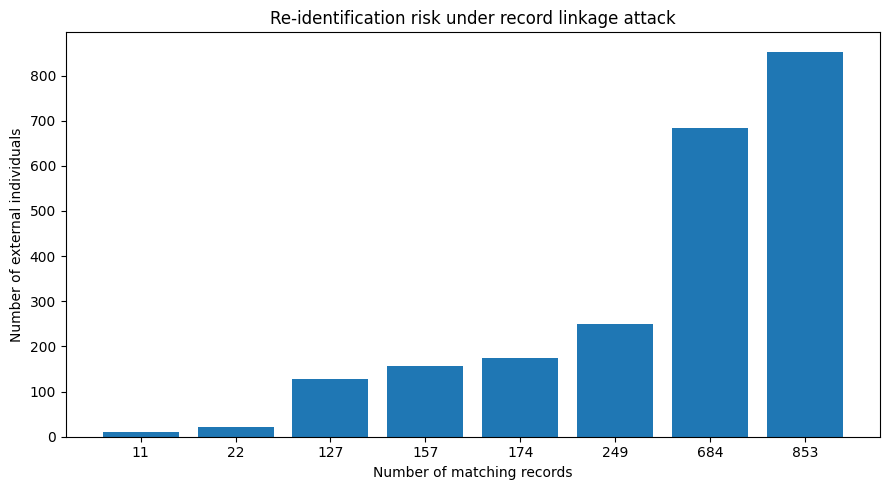

In [14]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


We evaluate record linkage risk through an exact-matching attack on the quasi-identifiers. <br>
For the traditionally anonymized dataset, the attacker’s auxiliary data is assumed to follow the same quasi-identifier granularity as the released data, including BMI binning. Under this setting, no external individual can be uniquely linked to the release, with all matches corresponding to equivalence classes of size at least five and often substantially larger, confirming the effectiveness of k-anonymity in preventing deterministic re-identification.
When the BMI attribute is suppressed, no individual can be univokely linked to the released dataset, and the equivalence classes appear larger than the binned BMI case.

In contrast, when applying the same attack to the synthetic dataset using the original quasi-identifiers, a large fraction of external individuals either have no matching synthetic records or are associated with a small number of matches, including many singleton matches. This behavior reflects the lack of enforced equivalence classes in synthetic data and the presence of fine-grained structural patterns. However, such matches do not imply direct re-identification of real individuals, but rather indicate potential points for attribute inference, which we evaluate in the following section.

#### Prosecutor risk

The linkage attack provides the equivalence class size for each external individual. Based on these values, we derive the prosecutor risk, defined as the inverse of the equivalence class size, which represents the probability of correct re-identification under the assumption that the attacker selects uniformly at random among all matching candidates.<br>
For individuals for whom no matching record exists in the released dataset, the prosecutor risk is defined to be zero, reflecting the failure of the exact-match linkage under the assumed attacker model.

In [15]:
import numpy as np

def prosecutor_risk(results):
    risks = []
    for v in results.values():
        if len(v) == 0:
            risks.append(0.0)
        else:
            risks.append(1 / len(v))
            
    return {
        "max_risk": max(risks),
        "mean_risk": np.mean(risks),
        "median_risk": np.median(risks),
        "pct_risk_ge_0.2": sum(r >= 0.2 for r in risks) / len(risks)
    }

print("Synthetic data")
print(prosecutor_risk(per_person_matches_synth))

print("Traditional anonymization (BMI)")
print(prosecutor_risk(per_person_matches_anon_bmi))

print("Traditional anonymization (NO BMI)")
print(prosecutor_risk(per_person_matches_anon_no_bmi))

Synthetic data
{'max_risk': 1.0, 'mean_risk': np.float64(0.3763727684017539), 'median_risk': np.float64(0.25), 'pct_risk_ge_0.2': 0.678963548528766}
Traditional anonymization (BMI)
{'max_risk': 0.2, 'mean_risk': np.float64(0.007026789635485288), 'median_risk': np.float64(0.0027548209366391185), 'pct_risk_ge_0.2': 0.0021958717610891525}
Traditional anonymization (NO BMI)
{'max_risk': 0.09090909090909091, 'mean_risk': np.float64(0.0035133948177426435), 'median_risk': np.float64(0.0014619883040935672), 'pct_risk_ge_0.2': 0.0}


| prosecutor risk             | Synthetic Dataset | Traditional dataset (BMI) | Traditional Dataset (NO BMI)|
|----------------------|--------------|--------------|--------------|
| max_risk |  1.0  |   0.2   | 0.09090909090909091|
| mean_risk   | 0.3763727684017539 |0.007026789635485288 |0.0035133948177426435|
| median_risk |  0.25 |  0.0027548209366391185  | 0.0014619883040935672|
| percentage risk $\ge$ 0.2 |   0.678963548528766 |   0.0021958717610891525 | 0.0|


Prosecutor risk results reveal a sharp contrast between synthetic and traditionally anonymized releases. <br>
For the synthetic dataset, prosecutor risk is substantially higher, with a maximum risk of 1.0 and nearly 68% of individuals exhibiting a re-identification probability of at least 0.2, reflecting the presence of small or singleton match sets under exact linkage. <br>
The traditionally anonymized datasets exhibit uniformly low prosecutor risk: the BMI-binned release has a maximum risk of 0.2, consistent with k = 5 anonymity, while the NO-BMI release further reduces the maximum risk to approximately 0.09, with no individuals exceeding the 0.2 threshold. <br>
These results confirm that traditional anonymization effectively limits re-identification probability under the prosecutor model, whereas higher prosecutor risk in synthetic data reflects increased structural linkability to synthetic profiles rather than direct identification of real individuals, underscoring the need to interpret these findings in conjunction with attribute inference analyses.

### Attribute disclosure risk

As a consequence of the re-identification risk assessment, we could measure the attribute disclosure risk: basically, the attacker might think to look into the distribution of the sensitive attributes of the matches that were found in the linkage attack. This is what l-diversity and t-closeness are meant to mitigate, but now we can measure it empirically.

For each external individual $i$ such that the match set $M_i \ne 0$ and for each sensitive attribute S we should compute two core risk measures:
* Maximum posterior probability: to measure the attacker's confidence to infer a sensitive value

    For individual i: $$ Risk_{max}(i) = max_{s \in S} P(S=s | QI = q_i)$$ Interpretation:
    * close to 1 $\rightarrow$ attacker can guess confidently
    * close to uniform $\rightarrow$ attacker uncertainty remains high (No sensitive value clearly dominates the attacker’s posterior belief, so disclosure risk is low)
* Conditional entropy: to measure the uncertainty $\rightarrow$ Entropy measures uncertainty because it quantifies the expected surprise of an outcome, and this surprise is maximized when all outcomes are equally likely and minimized when one outcome is certain.

    For individual i: $$ H(S| QI = q_i) = -\sum_s P(S=s|QI = q_i)logP(S=s|QI = q_i)$$ Interpretation:
    * low entropy $\rightarrow$ high disclosure risk
    * hig entropy $\rightarrow$ strong uncertainty <br>
    The maximum achievable entropy for a sensitive attribute is bounded by the logarithm of the number of distinct attribute values. Entropy values close to this bound indicate that the posterior distribution is close to uniform, implying high attacker uncertainty. $H_{max}=log_2|S|$

In [16]:
import numpy as np
from collections import Counter

def attribute_posteriors(results, released_df, sensitive_attr):

    posteriors = [] #to store, for each external value i, a posterior distribution over sensitive values
    n_matched = 0 # Counts how many external individuals have a non-empty match set (Mi != ∅)

    for _, idxs in results.items(): # results: dict {external_id: [matched_released_row_indices]}
        
        if len(idxs) == 0:     # If no matches for this external person, attacker can't form a posterior under this model
            continue

        n_matched += 1 # this external person contributes one posterior distribution

        # Extract the sensitive attribute values from the matched released records.
        # Casting to str makes Counter robust to mixed types, but it also turns NaN into "nan".
        values = released_df.loc[idxs, sensitive_attr].astype(str)

        counts = Counter(values)      # Count how many times each sensitive value appears in the match set Mi
        total = sum(counts.values())  # (|Mi|)
        posteriors.append({k: v / total for k, v in counts.items()})  # Convert counts into probabilities to approximate P(S=s | QI=qi)

    return posteriors, n_matched

def attribute_disclosure_metrics(posteriors, n_total, n_matched):
    # Coverage: fraction of external individuals for whom the linkage attack produced at least one match.
    # This corresponds to how often the inference attack is even applicable.
    coverage = n_matched / n_total

    # If nobody matched, there are no posteriors and thus no inference risk under this attacker model.
    if len(posteriors) == 0:
        return {
            "coverage": coverage,
            "mean_max_posterior": None,
            "median_max_posterior": None,
            "pct_max_posterior_ge_0.8": None,
            "mean_entropy": None,
            "median_entropy": None,
        }

    # Store per-individual (per posterior) summary stats
    max_posteriors = []
    entropies = []

    # Each p is a dict: {sensitive_value: probability}
    for p in posteriors:
        
        probs = np.array(list(p.values()), dtype=float)  # Convert dict values to a numeric array of probabilities

        max_posteriors.append(probs.max())          # Maximum posterior probability = attacker's best-guess confidence for that person

        # Conditional entropy of the posterior distribution:
        # Lower entropy => attacker more certain => higher disclosure risk
        entropies.append(-(probs * np.log2(probs)).sum())

    # Aggregate across attacked individuals
    return {
        "coverage": coverage,
        "mean_max_posterior": float(np.mean(max_posteriors)),
        "median_max_posterior": float(np.median(max_posteriors)),
        # Share of attacked individuals where attacker confidence is at least 0.8
        "pct_max_posterior_ge_0.8": float(np.mean(np.array(max_posteriors) >= 0.8)),
        "mean_entropy": float(np.mean(entropies)),
        "median_entropy": float(np.median(entropies)),
    }

In [17]:
n_total_synth = len(per_person_matches_synth)
n_total_anon_bmi = len(per_person_matches_anon_bmi)
n_total_anon_no_bmi = len(per_person_matches_anon_no_bmi)


for sa in critical_attributes:
    post_sy, matched_sy = attribute_posteriors(per_person_matches_synth, df_synth, sa)
    post_tr_bmi, matched_tr_bmi = attribute_posteriors(per_person_matches_anon_bmi, df_anon_bmi, sa)
    post_tr_no_bmi, matched_tr_no_bmi = attribute_posteriors(per_person_matches_anon_no_bmi, df_anon_no_bmi, sa)


    print(f"\nSensitive attribute: {sa}")
    print("Synthetic  :", attribute_disclosure_metrics(post_sy, n_total_synth, matched_sy))
    print("Traditional (BMI):", attribute_disclosure_metrics(post_tr_bmi, n_total_anon_bmi, matched_tr_bmi))
    print("Traditional (NO BMI):", attribute_disclosure_metrics(post_tr_no_bmi, n_total_anon_no_bmi, matched_tr_no_bmi))


Sensitive attribute: Diabetes_bin
Synthetic  : {'coverage': 0.7536231884057971, 'mean_max_posterior': 0.978753885003885, 'median_max_posterior': 1.0, 'pct_max_posterior_ge_0.8': 0.9446386946386947, 'mean_entropy': 0.060815085150355004, 'median_entropy': 0.0}
Traditional (BMI): {'coverage': 1.0, 'mean_max_posterior': 0.9653052261747914, 'median_max_posterior': 0.9653061224489796, 'pct_max_posterior_ge_0.8': 0.997364953886693, 'mean_entropy': 0.20361532023224385, 'median_entropy': 0.21741089228667318}
Traditional (NO BMI): {'coverage': 1.0, 'mean_max_posterior': 0.9653052261747914, 'median_max_posterior': 0.9736842105263158, 'pct_max_posterior_ge_0.8': 1.0, 'mean_entropy': 0.21131921937467385, 'median_entropy': 0.17556502585750278}

Sensitive attribute: Glucose Level
Synthetic  : {'coverage': 0.7536231884057971, 'mean_max_posterior': 0.515579328079328, 'median_max_posterior': 0.3333333333333333, 'pct_max_posterior_ge_0.8': 0.2744755244755245, 'mean_entropy': 1.2711492424403112, 'median_

 Model | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Diabetes Bin** | Synthetic Dataset|   0.7536231884057971| 0.978753885003885|  1.0|0.9446386946386947|0.060815085150355004|0.0|
|  | BMI dataset | 1.0| 0.9653052261747914| 0.9653061224489796|0.997364953886693|0.20361532023224385| 0.21741089228667318|
| | NO BMI dataset | 1.0|  0.9653052261747914| 0.9736842105263158|1.0|0.21131921937467385|0.17556502585750278|

 Model | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Glucose Level** | Synthetic Dataset|  0.7536231884057971| 0.5155793280793285| 0.3333333333333333|0.2744755244755245|1.2711492424403112|1.584962500721156|
|  | BMI dataset |  1.0| 0.07026789635485288| 0.06521739130434782|0.0|5.05750077717928|5.0312079404362775|
| | NO BMI dataset | 1.0|  0.06455862977602109| 0.05861664712778429|0.0|5.219945175492762|5.205944721913178|

 Model | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Oral Glucose Test** | Synthetic Dataset|  0.7536231884057971| 0.5063087375587376| 0.3333333333333333|0.2733100233100233|1.2896904234814923|1.584962500721156|
|  | BMI dataset |  1.0| 0.034255599472990776| 0.02857142857142857|0.0|6.358500789385681|6.461780185091363|
| | NO BMI dataset | 1.0|  0.025911286780852|0.021101992966002344|0.0|6.665401776560851|6.79046087411894|

 Model | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Insulin Level** | Synthetic Dataset| 0.7536231884057971| 0.4997527935027935|  0.3333333333333333|0.2733100233100233|1.3028023115933807|1.584962500721156|
|  | BMI dataset |  1.0| 0.014492753623188406| 0.011111111111111112|0.0|7.763770047433126| 8.217670633365096|
| | NO BMI dataset | 1.0| 0.00922266139657444|0.007309941520467836|0.0|8.597566553422665|9.110574641340976|

Attribute disclosure risk was evaluated by estimating posterior distributions over sensitive attributes conditional on the linkage match sets, and summarizing attacker confidence using maximum posterior probability and conditional entropy. <br>
For the binary attribute **Diabetes_bin** all datasets exhibit high disclosure risk once an individual is matchable, with mean maximum posterior probabilities above 0.96 and very low entropy. This indicates that diabetes status is highly predictable given the quasi-identifiers, regardless of the release mechanism. The synthetic dataset exhibits slightly higher confidence and lower entropy, driven by smaller match sets and frequent singleton matches, although attack coverage is reduced to approximately 75% due to unmatched individuals. <br>
For continuous clinical attributes (**Glucose Level, Oral Glucose Test, and Insulin Level**), the traditionally anonymized datasets show low maximum posterior probabilities and high entropy, reflecting substantial uncertainty within large equivalence classes. Suppressing BMI further increases entropy, indicating reduced inference risk. On the other hand, the synthetic dataset shows higher posterior concentration and lower entropy for these attributes. Overall, these results confirm that traditional anonymization effectively limits attribute inference through large equivalence classes, while synthetic data shifts privacy risk from identity disclosure toward conditional attribute inference for matchable individuals.

We note that inference results for continuous sensitive attributes are influenced by value granularity and should be interpreted comparatively; accordingly, these metrics are used to contrast release mechanisms rather than as absolute disclosure guarantees.

## Aligned representation

In addition to evaluating privacy risk on the released datasets as published, we perform a secondary analysis using an aligned quasi-identifier representation. This alignment is applied exclusively for evaluation purposes, in order to control for differences in attribute granularity introduced by the release mechanisms themselves. By harmonizing the quasi-identifier representation, we isolate the privacy protection attributable to the anonymization or synthesis process from effects driven solely by representation coarsening. This analysis does not imply additional modification of the released datasets, but rather models an attacker operating under comparable auxiliary information.

In [32]:
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers_1 = ['age_group', 'Gender', 'Physical Activity', 'BMI']
quasi_identifiers_2 = ['age_group', 'Gender', 'Physical Activity']

In [33]:
import pandas as pd

df_synth_no_bmi = pd.read_csv("../synthetic data/synthetic_NHANES.csv")

df_synth_bmi = df_synth_no_bmi.copy()

def bin_BMI(bmi):
    if bmi < 25: return "<25"
    else: return ">25"

df_synth_bmi['BMI'] = df_synth_bmi['BMI'].apply(bin_BMI)

df_synth_no_bmi = df_synth_no_bmi.drop(columns = "BMI")


#### Indistinguishability-based metrics:

##### k-anonymity

In [34]:
calculate_k_anon(df_synth_bmi, quasi_identifiers_1, "df_synth_bmi")
calculate_k_anon(df_synth_no_bmi, quasi_identifiers_2, "df_synth_no_bmi")

k-anonymity of df_synth_bmi: 10
k-anonymity of df_synth_no_bmi: 21


In [35]:
sizes_synth_bmi = eq_class_sizes(df_synth_bmi, quasi_identifiers_1)
sizes_synth_no_bmi = eq_class_sizes(df_synth_no_bmi, quasi_identifiers_2)

print("SYNTH BMI: min/median/mean:", sizes_synth_bmi.min(), sizes_synth_bmi.median(), sizes_synth_bmi.mean())
print("SYNTH NO BMI: min/median/mean:", sizes_synth_no_bmi.min(), sizes_synth_no_bmi.median(), sizes_synth_no_bmi.mean())

print("\nShare in classes <=5:")
print("SYNTH BMI:", (sizes_synth_bmi[sizes_synth_bmi<=5].sum() / len(df_synth_bmi)))
print("SYNTH NO BMI:", (sizes_synth_no_bmi[sizes_synth_no_bmi<=5].sum() / len(df_synth_no_bmi)))

SYNTH BMI: min/median/mean: 10 79.5 142.3125
SYNTH NO BMI: min/median/mean: 21 164.5 284.625

Share in classes <=5:
SYNTH BMI: 0.0
SYNTH NO BMI: 0.0


In the aligned-representation analysis, the synthetic dataset was evaluated under the same quasi-identifier granularity as the traditional releases, by binning BMI or suppressing it entirely (evaluation-only). <br>
Under BMI binning, synthetic k-anonymity increased from 1 to 10, with substantially larger equivalence classes (median size 79.5) and no records belonging to classes of size ≤ 5.<br>
When BMI was suppressed, synthetic k-anonymity increased further to 21 (median size 164.5), again eliminating small equivalence classes. <br>
These results indicate that the apparent structural uniqueness observed in the synthetic dataset under the as-released schema is strongly driven by attribute granularity (particularly continuous BMI), and that coarsening quasi-identifiers can markedly increase anonymity even without changing the underlying synthesis mechanism.

We can also notice that the binned BMI Synthetic Dataset and the traditional anonymized Dataset with the binned BMI attribute share the same mean size of the equivalence classes, the same goes for the suppressed BMI synthetic dataset and the traditional dataset with no BMI attribute; this suggests that the synthetic dataset has very similar QI marginal structure when the representation is aligned.

##### l-diversity

In [22]:
print("l-diversity for the synthetic dataset (BMI): \n")
l_diversity(df_synth_bmi, quasi_identifiers_1, critical_attributes)

print("l-diversity for the synthetic dataset (NO BMI): \n")
l_diversity(df_synth_no_bmi, quasi_identifiers_2, critical_attributes)

l-diversity for the synthetic dataset (BMI): 

1
Diabetes_bin
l-diversity: 1 

Glucose Level
l-diversity: 7 

Oral Glucose Test
l-diversity: 10 

Insulin Level
l-diversity: 10 

l-diversity for the synthetic dataset (NO BMI): 

2
Diabetes_bin
l-diversity: 2 

Glucose Level
l-diversity: 14 

Oral Glucose Test
l-diversity: 21 

Insulin Level
l-diversity: 21 



|  l-diversity         | Synthetic Dataset BMI | Synthetic Dataset NO BMI |
|----------------------|--------------|--------------|
| Diabetes_bin |  1 |   2   | 
| Glucose Level   | 7  | 14  |
| Oral Glucose Test |  10 |  21   | 
|  Insulin Level |   10  |   21  | 

When evaluating l-diversity under aligned quasi-identifier representations, the synthetic dataset exhibits a substantial increase in sensitive attribute diversity within equivalence classes. <br>
With BMI binned, l-diversity rises to values between 7 and 10 for continuous clinical attributes, while remaining at 1 for the binary attribute Diabetes_bin. <br>
Suppressing BMI further increases l-diversity, with values reaching up to 21 for continuous attributes and 2 for Diabetes_bin. <br>
These results mirror the behavior observed for traditional anonymization and reflect the enlargement of equivalence classes induced by quasi-identifier coarsening. Importantly, they indicate that the lack of l-diversity observed in the synthetic dataset under the as-released schema is primarily driven by fine-grained attribute representation rather than by an inherent absence of within-class variability. 

##### t-closeness

In [23]:
print("t_closeness for the synthetic dataset (BMI): ")
t_closeness(df_synth_bmi, quasi_identifiers_1, critical_attributes)

print("t_closeness for the synthetic dataset (NO BMI): ")
t_closeness(df_synth_no_bmi, quasi_identifiers_2, critical_attributes)

t_closeness for the synthetic dataset (BMI): 
0.3280976112734073
Diabetes_bin
t-closeness: 0.1267018006148441 

Glucose Level
t-closeness: 0.11129912718557272 

Oral Glucose Test
t-closeness: 0.16593669919967938 

Insulin Level
t-closeness: 0.3280976112734073 

t_closeness for the synthetic dataset (NO BMI): 
0.11626319490213766
Diabetes_bin
t-closeness: 0.015590689503733005 

Glucose Level
t-closeness: 0.06125648338086424 

Oral Glucose Test
t-closeness: 0.09499491821787731 

Insulin Level
t-closeness: 0.11626319490213766 



|  t-closeness             | Synthetic Dataset BMI | Synthetic Dataset NO BMI |
|----------------------|--------------|--------------|
| Diabetes_bin |  0.1267018006148441  |   0.015590689503733005    | 
| Glucose Level   | 0.11129912718557272   | 0.06125648338086424  |
| Oral Glucose Test |  0.16593669919967938  |  0.09499491821787731    | 
|  Insulin Level |   0.3280976112734073  |   0.11626319490213766   | 

Under aligned quasi-identifier representations, t-closeness for the synthetic dataset decreases compared to the as-released evaluation. <br>
With BMI binned, the synthetic dataset reaches moderate t-closeness values (overall t ≈ 0.33), while suppressing BMI further reduces divergence between equivalence-class and global distributions (overall t ≈ 0.12). <br>
Per-attribute results show consistently lower t-closeness for continuous clinical variables and minimal divergence for the binary attribute Diabetes_bin. <br>
As for the afore mentioned metrics, these findings indicate that the high t-closeness values observed for the synthetic dataset under the original schema are largely driven by fine-grained quasi-identifier representation and small equivalence classes. Once representation is aligned, the synthetic dataset exhibits distributional behavior comparable to traditionally anonymized releases, reinforcing the role of attribute granularity as a key determinant of structural privacy risk.

#### Re-identification Risk

##### Simulation

In [24]:
external_dataset = pd.read_csv("../traditional data/external_dataset_BMI.csv", dtype=str)   # attacker knowledge

hist, per_person_matches_synth_bmi = re_identify_individuals(
    external_dataset,
    df_synth_bmi,
    qi=quasi_identifiers_1
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

6 individuals have exactly 10 matches.
5 individuals have exactly 11 matches.
6 individuals have exactly 12 matches.
16 individuals have exactly 24 matches.
56 individuals have exactly 66 matches.
40 individuals have exactly 67 matches.
111 individuals have exactly 72 matches.
46 individuals have exactly 75 matches.
84 individuals have exactly 84 matches.
118 individuals have exactly 92 matches.
165 individuals have exactly 99 matches.
87 individuals have exactly 104 matches.
270 individuals have exactly 309 matches.
363 individuals have exactly 361 matches.
414 individuals have exactly 415 matches.
490 individuals have exactly 476 matches.


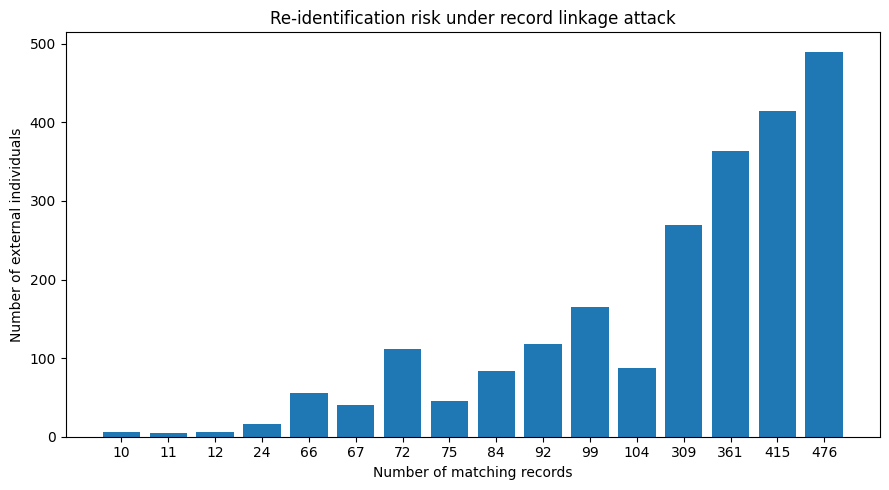

In [25]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


In [26]:
external_dataset = pd.read_csv("../traditional data/external_dataset_NO_BMI.csv", dtype=str)   # attacker knowledge

hist, per_person_matches_synth_no_bmi = re_identify_individuals(
    external_dataset,
    df_synth_no_bmi,
    qi=quasi_identifiers_2
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

11 individuals have exactly 21 matches.
22 individuals have exactly 36 matches.
157 individuals have exactly 147 matches.
174 individuals have exactly 158 matches.
127 individuals have exactly 171 matches.
249 individuals have exactly 183 matches.
684 individuals have exactly 724 matches.
853 individuals have exactly 837 matches.


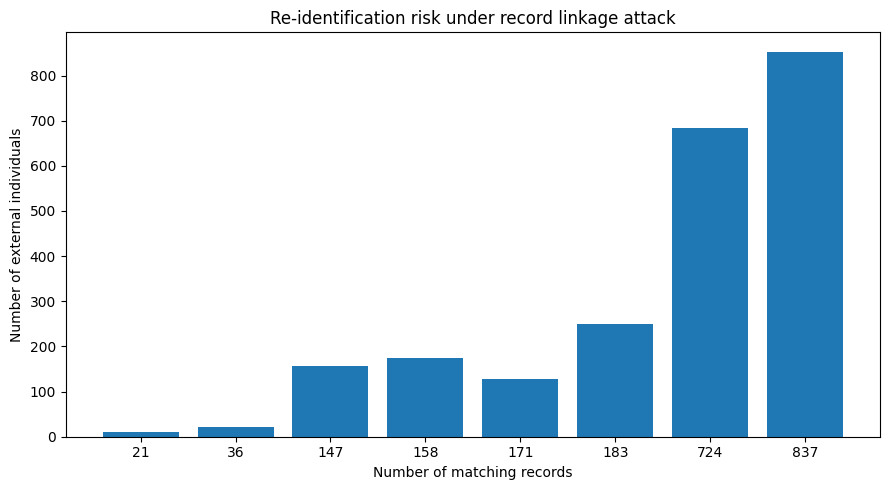

In [27]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


##### Prosecutor risk

In [28]:
print("Synthetic data (BMI)")
print(prosecutor_risk(per_person_matches_synth_bmi))

print("Synthetic data (NO BMI)")
print(prosecutor_risk(per_person_matches_synth_no_bmi))

Synthetic data (BMI)
{'max_risk': 0.1, 'mean_risk': np.float64(0.006374112612670641), 'median_risk': np.float64(0.002770083102493075), 'pct_risk_ge_0.2': 0.0}
Synthetic data (NO BMI)
{'max_risk': 0.047619047619047616, 'mean_risk': np.float64(0.0032373415617362095), 'median_risk': np.float64(0.0013812154696132596), 'pct_risk_ge_0.2': 0.0}


| prosecutor risk             | Synthetic Dataset (BMI) | Synthetic Dataset (NO BMI) |
|----------------------|--------------|--------------|
| max_risk |  0.1  |    0.047619047619047616   | 
| mean_risk   | 0.006374112612670641  | 0.0032373415617362095  |
| median_risk |  0.002770083102493075 |  0.0013812154696132596  | 
| percentage risk $\ge$ 0.2 |   0.0  |   0.0  | 

When evaluating record linkage under aligned quasi-identifier representations, the synthetic dataset exhibits substantially reduced linkage risk. <br>
With BMI binned, each external individual matches a large number of synthetic records, while suppressing BMI further increases match set sizes. <br>
Correspondingly, prosecutor risk decreases sharply: maximum re-identification probability falls to 0.10 under BMI binning and below 0.05 when BMI is suppressed, with no individuals exceeding the 0.2 risk threshold in either case. These results closely mirror those observed for traditionally anonymized datasets and indicate that the elevated linkage risk observed for synthetic data under the as-released schema is primarily attributable to fine-grained attribute representation rather than to the synthesis process itself.

#### Attribute disclosure risk

In [31]:
n_total_bmi = len(per_person_matches_synth_bmi)
n_total_no_bmi = len(per_person_matches_synth_no_bmi)


for sa in critical_attributes:
    post_sy_bmi, matched_sy_bmi = attribute_posteriors(per_person_matches_synth_bmi, df_synth_bmi, sa)
    post_sy_no_bmi, matched_sy_no_bmi = attribute_posteriors(per_person_matches_synth_no_bmi, df_synth_no_bmi, sa)


    print(f"\nSensitive attribute: {sa}")
    print("Synthetic BMI:", attribute_disclosure_metrics(post_sy_bmi, n_total_bmi, matched_sy_bmi))

    print("Synthetic NO BMI:", attribute_disclosure_metrics(post_sy_no_bmi, n_total_no_bmi, matched_sy_no_bmi))




Sensitive attribute: Diabetes_bin
Synthetic BMI: {'coverage': 1.0, 'mean_max_posterior': 0.9601245571304927, 'median_max_posterior': 0.9565217391304348, 'pct_max_posterior_ge_0.8': 1.0, 'mean_entropy': 0.23885417624648683, 'median_entropy': 0.2580186686648155}
Synthetic NO BMI: {'coverage': 1.0, 'mean_max_posterior': 0.960413520139537, 'median_max_posterior': 0.9629629629629629, 'pct_max_posterior_ge_0.8': 1.0, 'mean_entropy': 0.23957955559188077, 'median_entropy': 0.228538143953528}

Sensitive attribute: Glucose Level
Synthetic BMI: {'coverage': 1.0, 'mean_max_posterior': 0.053093270487760795, 'median_max_posterior': 0.045307443365695796, 'pct_max_posterior_ge_0.8': 0.0, 'mean_entropy': 5.393754940734358, 'median_entropy': 5.450019910679288}
Synthetic NO BMI: {'coverage': 1.0, 'mean_max_posterior': 0.047631204453028465, 'median_max_posterior': 0.04181600955794504, 'pct_max_posterior_ge_0.8': 0.0, 'mean_entropy': 5.557378416431258, 'median_entropy': 5.629122894170369}

Sensitive attri

 Sensitive Attribute | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Diabetes Bin** | Synthetic Dataset BMI|   1.0|0.9601245571304927|   0.9565217391304348|1.0|0.23885417624648683|0.2580186686648155|
| | Synthetic Dataset NO BMI  |  1.0|   0.960413520139537|  0.9629629629629629|1.0|0.23957955559188077|0.228538143953528|

 Sensitive Attribute  | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Glucose Level** | Synthetic Dataset BMI|   1.0|  0.053093270487760795|   0.045307443365695796|0.0|5.393754940734358|5.450019910679288|
| | Synthetic Dataset NO BMI  |  1.0|  0.047631204453028465| 0.04181600955794504|0.0|5.557378416431258|5.629122894170369|

 Sensitive Attribute  | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Oral Glucose Test** | Synthetic Dataset BMI|   1.0| 0.032127046816423824|  0.027700831024930747|0.0|6.485448247985256| 6.660654242613052|
| | Synthetic Dataset NO BMI  |  1.0|   0.0232368203256151| 0.022700119474313024|0.0|6.810113512952222|7.018990766622151|

 Sensitive Attribute  | Dataset |Coverage |Mean max posterior| median max posterior| pct max posterior $\ge$ 0.8| mean entropy| median entropy|
| :--- | :--- | :--- | :--- | :--- |:--- |:--- |:--- |
|**Insulin Level** | Synthetic Dataset BMI|  1.0| 0.013294438229503458|  0.008403361344537815|0.0|7.746723804957083|8.253445677844715|
| | Synthetic Dataset NO BMI  | 1.0|   0.007612475211720831| 0.0047789725209080045|0.0|8.620911750319095|9.278485855996893|

Attribute disclosure risk for the synthetic dataset was further evaluated under aligned quasi-identifier representations by binning BMI and suppressing it entirely. <br>
Under both alignments, inference risk for continuous clinical attributes is substantially reduced compared to the as-released synthetic data. Mean maximum posterior probabilities fall below 0.06 for glucose-related measures and below 0.02 for insulin levels, while conditional entropy increases markedly, indicating high attacker uncertainty. No individuals exhibit high-confidence inference (maximum posterior ≥ 0.8) for any continuous attribute. <br>
For the binary attribute Diabetes_bin, posterior concentration remains high, consistent with observations for traditionally anonymized datasets and reflecting the limited domain of binary sensitive attributes rather than a synthetic-specific vulnerability.

 Overall, these results demonstrate that once quasi-identifier granularity is aligned, synthetic data exhibits attribute disclosure behavior comparable to traditional anonymization, confirming that elevated inference risk in the as-released synthetic dataset is primarily driven by fine-grained attribute representation.